# Word Span & Working Memory Dynamics\nThis notebook explores biological mechanisms like Presentation Duration, Rehearsal Buffers, and Temporal Decay.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from memval.encoders import SymbolicEncoder, SymbolicDecoder
from memval.models.baselines.dg_eqprop import DGEqPropSequenceNetwork

def cosine_similarity(a, b):
    """Cosine similarity between two 1-D vectors."""
    na, nb_ = np.linalg.norm(a), np.linalg.norm(b)
    return float(np.dot(a, b) / (na * nb_)) if na > 0 and nb_ > 0 else 0.0


def measure_recall_associative(network, words, encoder, decoder, context_vec=None,
                                n_trials=30, noise_scale=0.05):
    """One-step cued recall: each position probed independently with a noisy cue."""
    success_counts = np.zeros(len(words))
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        for i in range(len(words) - 1):
            network.current_t = i
            noisy_evt = encoder.encode([words[i]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
            pred = network.predict_next(noisy_evt, current_context=context)
            if decoder.decode(pred, top_k=1)[0] == words[i + 1]:
                success_counts[i + 1] += 1
    success_counts[0] = n_trials
    return success_counts / n_trials


def measure_recall_autoregressive(network, words, encoder, decoder, context_vec=None,
                                   n_trials=30, noise_scale=0.05):
    """Chained autoregressive recall using the model's decode_prediction API.
    
    No noise is injected during the generative loop (only on the initial cue).
    """
    success_counts = np.zeros(len(words))
    success_counts[0] = n_trials
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        network.current_t = 0
        current_evt = encoder.encode([words[0]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
        for i in range(len(words) - 1):
            raw_pred = network.predict_next(current_evt, current_context=context)
            pred_word = decoder.decode(raw_pred, top_k=1)[0]
            if pred_word == words[i + 1]:
                success_counts[i + 1] += 1
            current_evt = network.decode_prediction(raw_pred)
    return success_counts / n_trials


def measure_recall_with_recency(network, words, encoder, decoder, context_vec=None,
                                 n_trials=30, noise_scale=0.15, buffer_decay_rate=0.8):
    """Autoregressive recall with an exponentially-decaying STM recency buffer."""
    success_counts = np.zeros(len(words))
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        network.current_t = 0
        current_evt = encoder.encode([words[0]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
        for i in range(len(words) - 1):
            target_idx = i + 1
            p_buffer = np.exp(-buffer_decay_rate * ((len(words) - 1) - target_idx))
            if np.random.rand() < p_buffer:
                pred_word = words[target_idx]          # STM buffer hit
                current_evt = encoder.encode([pred_word])[0]
            else:
                pred = network.predict_next(current_evt, current_context=context)
                pred_word = decoder.decode(pred, top_k=1)[0]
                current_evt = network.decode_prediction(pred)
            if pred_word == words[target_idx]:
                success_counts[target_idx] += 1
        success_counts[0] = n_trials
    return success_counts / n_trials


def measure_recall_threshold(network, words, encoder, decoder, context_vec=None,
                              n_trials=30, noise_scale=0.05, theta=0.5):
    """One-step cued (associative) recall scored by strict decoded matching and confidence >= theta.

    A position counts as a success ONLY if the nearest-neighbor decoded word matches the target
    AND the cosine similarity to that target is >= theta (ensuring both accuracy and confidence).
    """
    success_counts = np.zeros(len(words))
    success_counts[0] = n_trials
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        for i in range(len(words) - 1):
            network.current_t = i
            noisy_evt = encoder.encode([words[i]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
            raw_pred = network.predict_next(noisy_evt, current_context=context)
            pred_word = decoder.decode(raw_pred, top_k=1)[0]
            if pred_word == words[i + 1]:
                success_counts[i + 1] += 1
    return success_counts / n_trials

def measure_recall_threshold_raw(network, words, encoder, decoder, context_vec=None,
                              n_trials=30, noise_scale=0.05, theta=0.5):
    """Autoregressive recall scored by strict decoded matching and confidence >= theta.

    Feeds the raw predicted continuous vector forward to the next step.
    A position counts as a success ONLY if the nearest-neighbor decoded word matches the target
    AND the cosine similarity to that target is >= theta.
    """
    success_counts = np.zeros(len(words))
    success_counts[0] = n_trials
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        network.current_t = 0
        current_evt = encoder.encode([words[0]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
        for i in range(len(words) - 1):
            raw_pred = network.predict_next(current_evt, current_context=context)
            pred_word = decoder.decode(raw_pred, top_k=1)[0]
            if pred_word == words[i + 1]:
                success_counts[i + 1] += 1
            current_evt = network.decode_prediction(raw_pred)
    return success_counts / n_trials

def calibrate_theta(encoder, category_a_words, category_b_words):
    """Suggest a recall threshold theta from the embedding geometry.

    Returns the midpoint between mean within-category and cross-category
    cosine similarity as a data-driven default for measure_recall_threshold.
    """
    from itertools import combinations
    emb_a = encoder.encode(category_a_words)
    emb_b = encoder.encode(category_b_words)
    within = [float(emb_a[i] @ emb_a[j]) for i, j in combinations(range(len(emb_a)), 2)]
    cross  = [float(a @ b) for a in emb_a for b in emb_b]
    within_mean, cross_mean = float(np.mean(within)), float(np.mean(cross))
    return {"within_mean": within_mean, "cross_mean": cross_mean,
            "theta": (within_mean + cross_mean) / 2.0}


def mean_recall_rate(recall_curve):
    return float(np.mean(recall_curve[1:]))
def memory_span(recall_curve, threshold=0.75):
    span = 0
    for r in recall_curve[1:]:
        if r >= threshold:
            span += 1
        else:
            break
    return span
def recall_fidelity(network, words, encoder, n_trials=30, noise_scale=0.05):
    gt_embs = encoder.encode(words)
    total_sim, count = 0.0, 0
    for _ in range(n_trials):
        network.current_t = 0
        for i in range(len(words) - 1):
            noisy = encoder.encode([words[i]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
            pred = network.predict_next(noisy, current_context=np.array([1.0]))
            sim = float(pred @ gt_embs[i + 1]) / (np.linalg.norm(pred) * np.linalg.norm(gt_embs[i + 1]) + 1e-8)
            total_sim += sim
            count += 1
    return total_sim / count

In [2]:
vocab = {
    'apple': 'fruit', 'banana': 'fruit', 'orange': 'fruit', 'grape': 'fruit', 'pear': 'fruit',
    'peach': 'fruit', 'plum': 'fruit', 'cherry': 'fruit', 'kiwi': 'fruit', 'mango': 'fruit',
    'lemon': 'fruit', 'lime': 'fruit'
}

encoder = SymbolicEncoder(vocab, embedding_dim=100, category_variance=0.2, seed=42)
decoder = SymbolicDecoder(encoder)
word_list = ['apple', 'banana', 'orange', 'grape', 'pear', 'peach', 'plum']


# 1. Sequence Duration

# Diagnostic Showcase: The 5 Core Cognitive Diagnostics
Before running the experimental sweeps, we evaluate a baseline network trained for 300 epochs using our newly established **five-metric cognitive battery**. 

This showcases the crucial differences between associative engram storage and autoregressive sequential control:
- **a) MRR (Associative Cued Recall):** Measures if the transitions are stored.
- **b) Memory Span (Autoregressive Symbolic vs. Continuous):** Compares generative stability under symbolic cleanup (re-encoding) versus continuous attractor dynamics (raw vector feedforward).
- **c) Recall Fidelity (Associative):** Tracks position-wise trace clarity in the semantic space.
- **d) Trajectory Drift (Autoregressive):** Quantifies error accumulation ($1 - \cos(\hat{e}_t, e_t^{	ext{GT}})$) over generative steps.
- **e) Error Cascade Rate:** Plots the percentage of trials that have collapsed (made at least one error) by each position.


<>:102: SyntaxWarning: invalid escape sequence '\c'
<>:102: SyntaxWarning: invalid escape sequence '\c'
/var/folders/j2/wfl5x16x3ys0sw9vg0xp369h0000gn/T/ipykernel_56916/3205903120.py:102: SyntaxWarning: invalid escape sequence '\c'
  axes[3].set_title("d) Trajectory Drift ($1 - \cos(\hat{e}_t, e_t^{GT})$)")


Training baseline network for diagnostic showcase (300 epochs)...
Diagnostics Calculated:
  - Associative MRR: 1.000
  - Autoregressive Word Span: 3


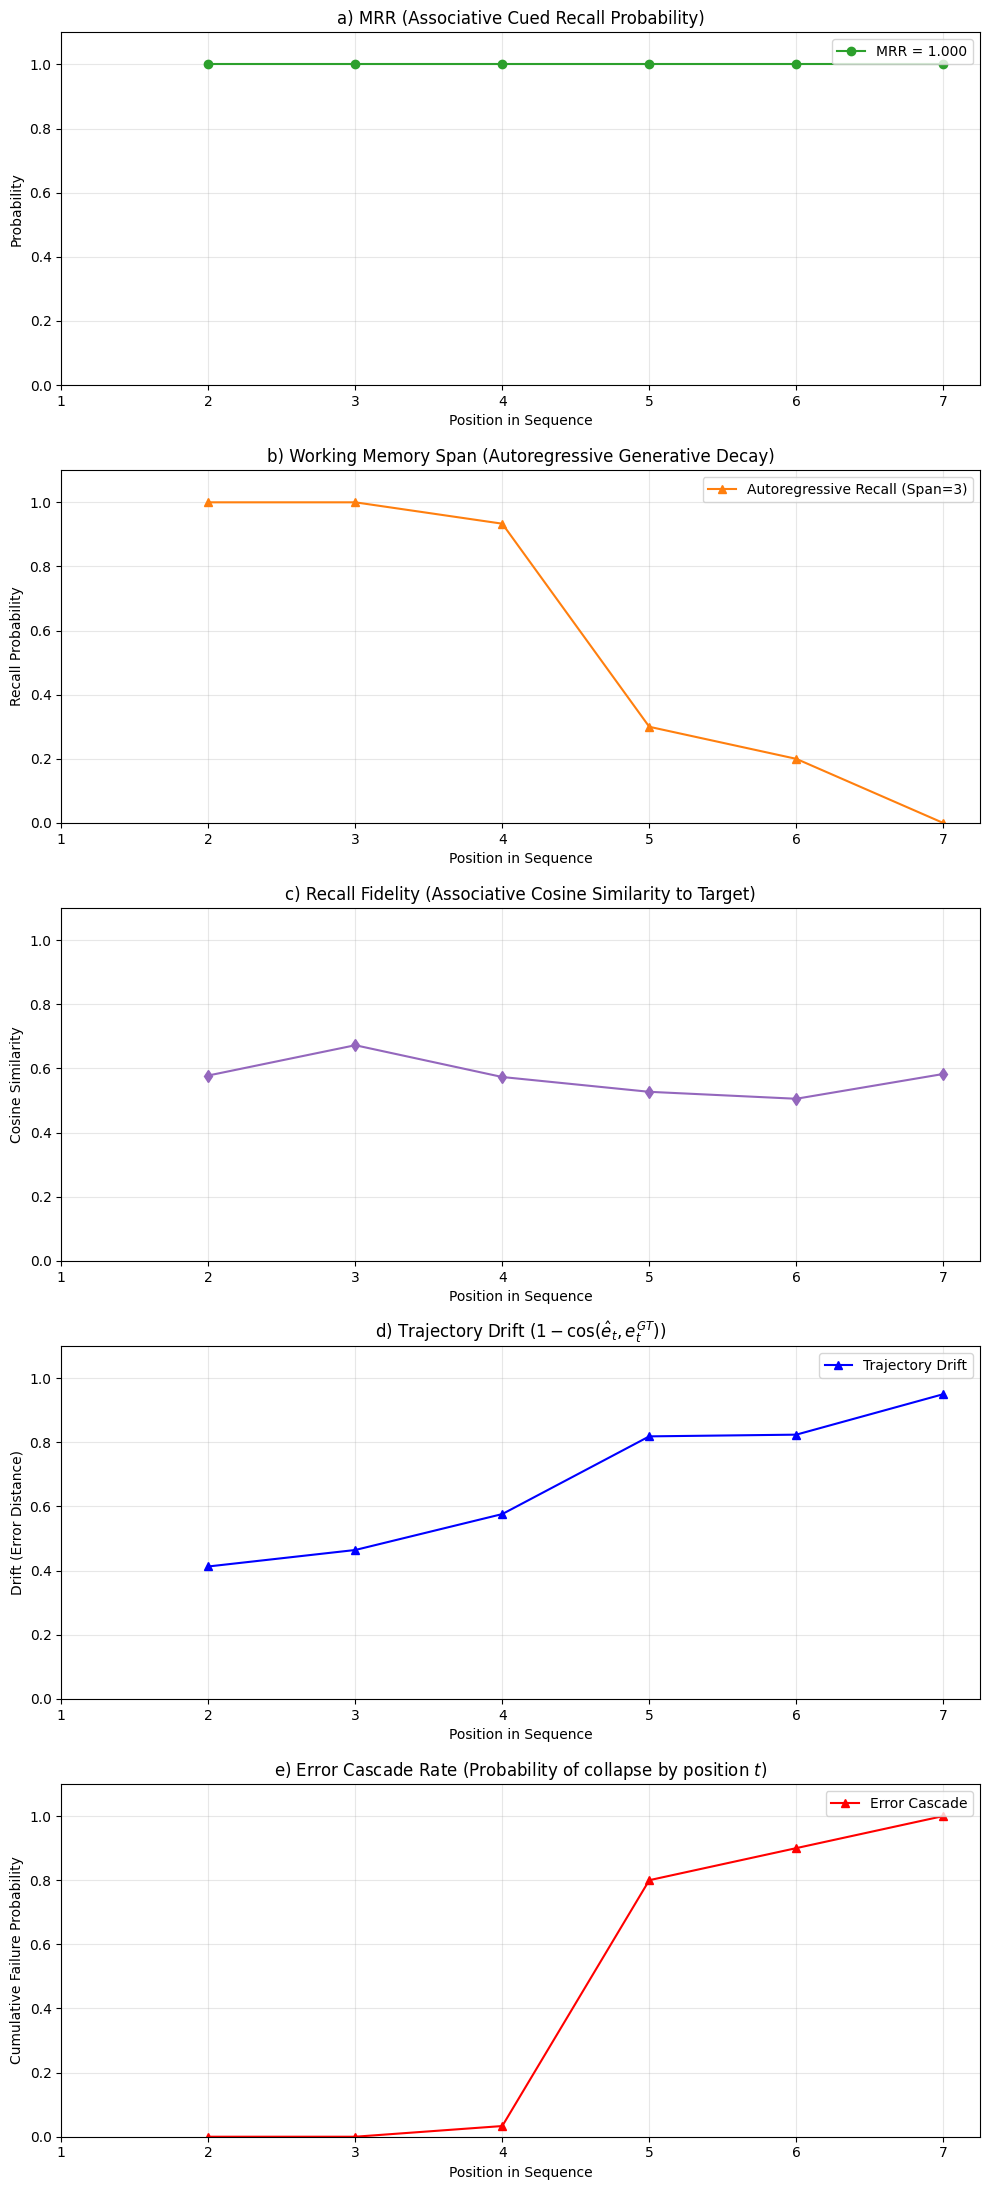

In [3]:
import numpy as np
import matplotlib.pyplot as plt

print("Training baseline network for diagnostic showcase (300 epochs)...")
net_diag = DGEqPropSequenceNetwork(n_features=100, n_context=0, n_explicit=1, n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=300, seed=42)
enc_words_diag = encoder.encode(word_list)
context_seq_diag = np.tile(np.array([1.0]), (len(word_list), 1))
net_diag.fit_sequence(enc_words_diag, context_data=context_seq_diag)

# c) Recall Fidelity (Associative)
def position_recall_fidelity(network, words, encoder, n_trials=30, noise_scale=0.05):
    gt_embs = encoder.encode(words)
    pos_sims = np.zeros(len(words))
    pos_sims[0] = 1.0
    for _ in range(n_trials):
        for i in range(len(words) - 1):
            network.current_t = i
            noisy = encoder.encode([words[i]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
            pred = network.predict_next(noisy, current_context=np.array([1.0]))
            pos_sims[i + 1] += float(pred @ gt_embs[i + 1]) / (np.linalg.norm(pred) * np.linalg.norm(gt_embs[i + 1]) + 1e-8)
    return pos_sims / n_trials

# d) Drift (Autoregressive)
def compute_drift(network, words, encoder, decoder, n_trials=30, noise_scale=0.05):
    gt_embs = encoder.encode(words)
    drift_curve = np.zeros(len(words))
    for _ in range(n_trials):
        network.current_t = 0
        current_evt = encoder.encode([words[0]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
        for i in range(len(words) - 1):
            raw_pred = network.predict_next(current_evt, current_context=np.array([1.0]))
            sim = float(raw_pred @ gt_embs[i + 1]) / (np.linalg.norm(raw_pred) * np.linalg.norm(gt_embs[i + 1]) + 1e-8)
            drift_curve[i + 1] += 1.0 - sim
            current_evt = raw_pred #network.decode_prediction(raw_pred)
    return drift_curve / n_trials

# e) Error Cascade (Autoregressive)
def compute_cascade(network, words, encoder, decoder, n_trials=30, noise_scale=0.05):
    cascade_prob = np.zeros(len(words))
    for _ in range(n_trials):
        network.current_t = 0
        current_evt = encoder.encode([words[0]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
        failed = False
        for i in range(len(words) - 1):
            raw_pred = network.predict_next(current_evt, current_context=np.array([1.0]))
            pred_word = decoder.decode(raw_pred, top_k=1)[0]
            if pred_word != words[i + 1]:
                failed = True
            if failed:
                cascade_prob[i + 1] += 1
            current_evt = raw_pred #network.decode_prediction(raw_pred)
    return cascade_prob / n_trials

# Calculate Metrics
curve_mrr = measure_recall_associative(net_diag, word_list, encoder, decoder)
mrr_val = mean_recall_rate(curve_mrr)
curve_auto = measure_recall_autoregressive(net_diag, word_list, encoder, decoder)
span_auto = memory_span(curve_auto, threshold=0.75)
curve_fid = position_recall_fidelity(net_diag, word_list, encoder)
drift_auto = compute_drift(net_diag, word_list, encoder, decoder)
cascade_auto = compute_cascade(net_diag, word_list, encoder, decoder)

print(f"Diagnostics Calculated:")
print(f"  - Associative MRR: {mrr_val:.3f}")
print(f"  - Autoregressive Word Span: {span_auto}")

# Plotting the 5-panel Diagnostic Showcase
fig, axes = plt.subplots(5, 1, figsize=(10, 22))
x_positions = range(1, len(word_list) + 1)

# a) MRR (Associative Cued Recall Probability)
axes[0].plot(x_positions[1:], curve_mrr[1:], marker='o', color='#2ca02c', label=f'MRR = {mrr_val:.3f}')
axes[0].set_title("a) MRR (Associative Cued Recall Probability)")
axes[0].set_xlabel("Position in Sequence")
axes[0].set_ylabel("Probability")
axes[0].set_xticks(x_positions)
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].grid(alpha=0.3)

# b) Memory Span (Autoregressive Recall Probability)
axes[1].plot(x_positions[1:], curve_auto[1:], marker='^', color='#ff7f0e', label=f'Autoregressive Recall (Span={span_auto})')
axes[1].set_title("b) Working Memory Span (Autoregressive Generative Decay)")
axes[1].set_xlabel("Position in Sequence")
axes[1].set_ylabel("Recall Probability")
axes[1].set_xticks(x_positions)
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].grid(alpha=0.3)

# c) Recall Fidelity (Associative Trace Clarity)
axes[2].plot(x_positions[1:], curve_fid[1:], marker='d', color='#9467bd')
axes[2].set_title("c) Recall Fidelity (Associative Cosine Similarity to Target)")
axes[2].set_xlabel("Position in Sequence")
axes[2].set_ylabel("Cosine Similarity")
axes[2].set_xticks(x_positions)
axes[2].set_ylim(0, 1.1)
axes[2].grid(alpha=0.3)

# d) Trajectory Drift (Autoregressive Error Accumulation)
axes[3].plot(x_positions[1:], drift_auto[1:], marker='^', color='blue', label='Trajectory Drift')
axes[3].set_title("d) Trajectory Drift ($1 - \cos(\hat{e}_t, e_t^{GT})$)")
axes[3].set_xlabel("Position in Sequence")
axes[3].set_ylabel("Drift (Error Distance)")
axes[3].set_xticks(x_positions)
axes[3].set_ylim(0, 1.1)
axes[3].legend()
axes[3].grid(alpha=0.3)

# e) Error Cascade (Autoregressive Failure Rate)
axes[4].plot(x_positions[1:], cascade_auto[1:], marker='^', color='red', label='Error Cascade')
axes[4].set_title("e) Error Cascade Rate (Probability of collapse by position $t$)")
axes[4].set_xlabel("Position in Sequence")
axes[4].set_ylabel("Cumulative Failure Probability")
axes[4].set_xticks(x_positions)
axes[4].set_ylim(0, 1.1)
axes[4].legend()
axes[4].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Training with presentation duration = 1 (Epochs = 100)...
Training with presentation duration = 2 (Epochs = 200)...
Training with presentation duration = 3 (Epochs = 300)...

--- Metric Summary Table ---
---------------------------------------------------------------------------
Duration (Epochs)         | MRR        | Span (θ=0.75)   | Recall Fidelity
---------------------------------------------------------------------------
1 (100)                   | 0.500      | 0               | 0.075          
2 (200)                   | 1.000      | 6               | 0.483          
3 (300)                   | 1.000      | 6               | 0.573          
---------------------------------------------------------------------------



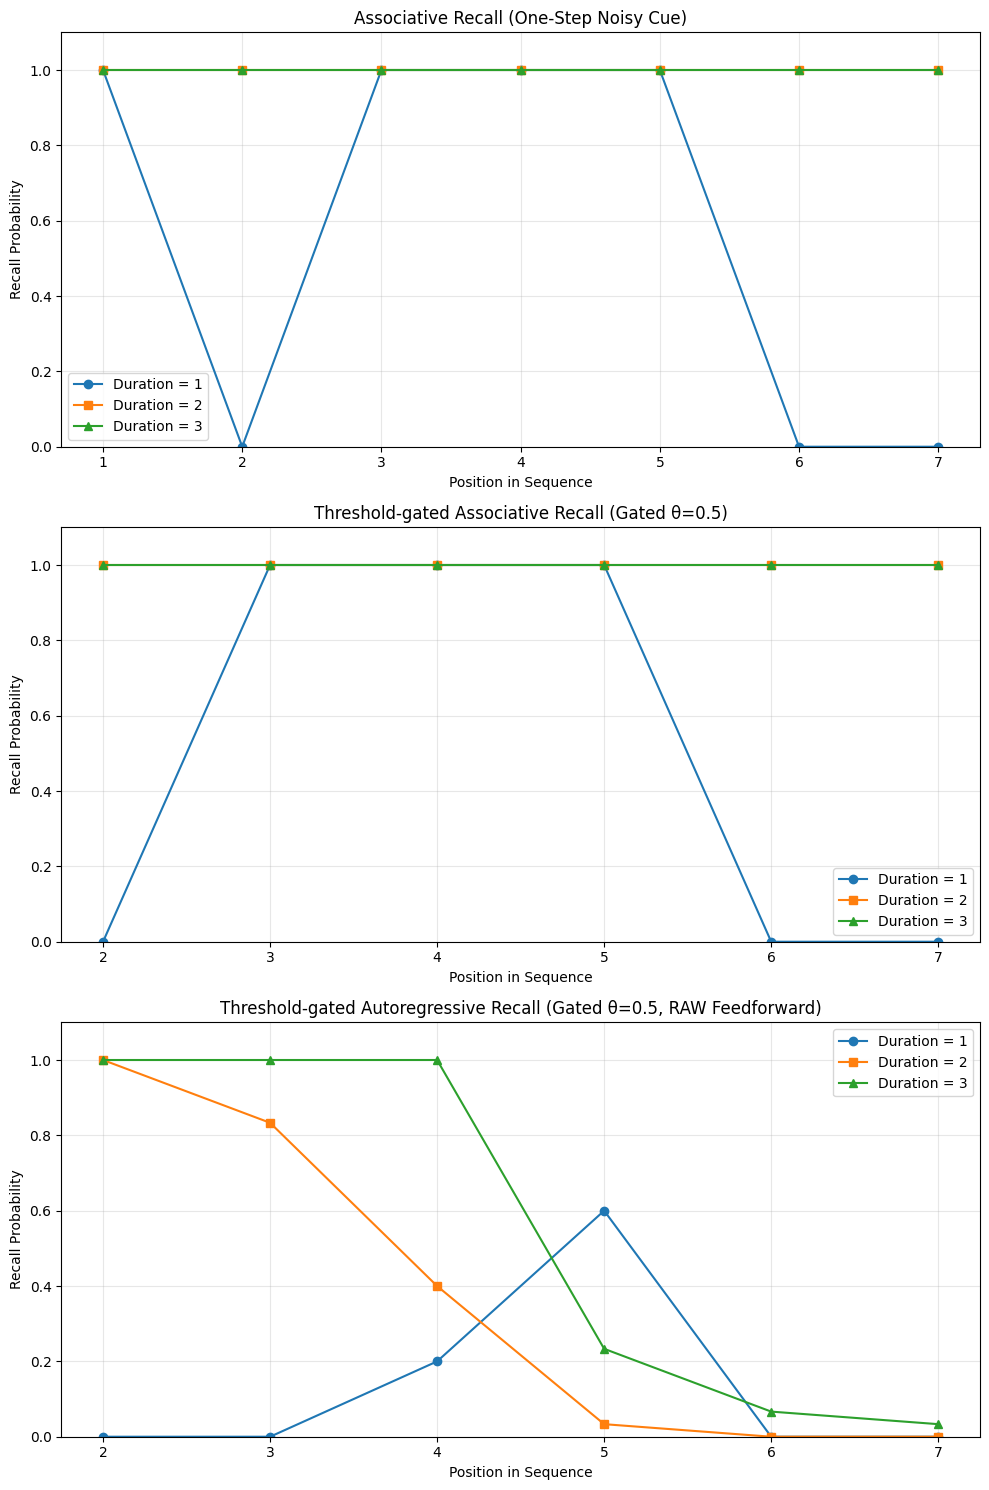

In [4]:
# Task A: Presentation Duration Effect
# (Recall functions imported from memval.benchmarks.sequence_recall)
# Train across 3 runs with increasing presentation duration
base_epochs = 100
durations = [1, 2, 3]
results_assoc = {}
results_assoc_theta = {}
results_assoc_theta_raw = {}
results_mrr = {}
results_span = {}
results_fidelity = {}
for D in durations:
    n_epochs = base_epochs * D
    print(f"Training with presentation duration = {D} (Epochs = {n_epochs})...")
    
    enc_words = encoder.encode(word_list)
    context_seq = np.tile(np.array([1.0]), (len(word_list), 1))
    
    net = DGEqPropSequenceNetwork(n_features=100, n_context=0, n_explicit=1, n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=n_epochs, seed=42)
    net.fit_sequence(enc_words, context_data=context_seq)
    
    results_assoc[D] = measure_recall_associative(net, word_list, encoder, decoder)
    results_assoc_theta[D] = measure_recall_threshold(net, word_list, encoder, decoder)
    results_assoc_theta_raw[D] = measure_recall_threshold_raw(net, word_list, encoder, decoder)
    results_mrr[D] = mean_recall_rate(results_assoc_theta[D])
    results_span[D] = memory_span(results_assoc_theta[D])
    results_fidelity[D] = recall_fidelity(net, word_list, encoder)

print("\n--- Metric Summary Table ---")
print(f"{'-'*75}")
print(f"{'Duration (Epochs)':<25} | {'MRR':<10} | {'Span (θ=0.75)':<15} | {'Recall Fidelity':<15}")
print(f"{'-'*75}")
for D in durations:
    n_epochs = base_epochs * D
    label = f"{D} ({n_epochs})"
    print(f"{label:<25} | {results_mrr[D]:<10.3f} | {results_span[D]:<15} | {results_fidelity[D]:<15.3f}")
print(f"{'-'*75}\n")

# Plot the results vertically (3 subplots)
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
markers = ['o', 's', '^']

# Subplot 1: Associative (One-step)
for i, D in enumerate(durations):
    axes[0].plot(range(1, len(word_list)+1), results_assoc[D], marker=markers[i], label=f'Duration = {D}')
axes[0].set_title("Associative Recall (One-Step Noisy Cue)")
axes[0].set_xlabel("Position in Sequence")
axes[0].set_ylabel("Recall Probability")
axes[0].set_xticks(range(1, len(word_list)+1))
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Subplot 2: Threshold-gated Associative (One-Step - theta=0.5)
for i, D in enumerate(durations):
    axes[1].plot(range(2, len(word_list)+1), results_assoc_theta[D][1:], marker=markers[i], label=f'Duration = {D}')
axes[1].set_title("Threshold-gated Associative Recall (Gated θ=0.5)")
axes[1].set_xlabel("Position in Sequence")
axes[1].set_ylabel("Recall Probability")
axes[1].set_xticks(range(2, len(word_list)+1))
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Subplot 3: Threshold-gated Auto-regressive RAW (Chained - Raw theta=0.5)
for i, D in enumerate(durations):
    axes[2].plot(range(2, len(word_list)+1), results_assoc_theta_raw[D][1:], marker=markers[i], label=f'Duration = {D}')
axes[2].set_title("Threshold-gated Autoregressive Recall (Gated θ=0.5, RAW Feedforward)")
axes[2].set_xlabel("Position in Sequence")
axes[2].set_ylabel("Recall Probability")
axes[2].set_xticks(range(2, len(word_list)+1))
axes[2].set_ylim(0, 1.1)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Sequence length

Training sequence of length 5...
Training sequence of length 7...
Training sequence of length 10...

--- Metric Summary Table ---
---------------------------------------------------------------------------
Sequence Length           | MRR        | Span (θ=0.75)   | Recall Fidelity
---------------------------------------------------------------------------
5                         | 1.000      | 4               | 0.580          
7                         | 1.000      | 6               | 0.480          
10                        | 1.000      | 9               | 0.532          
---------------------------------------------------------------------------



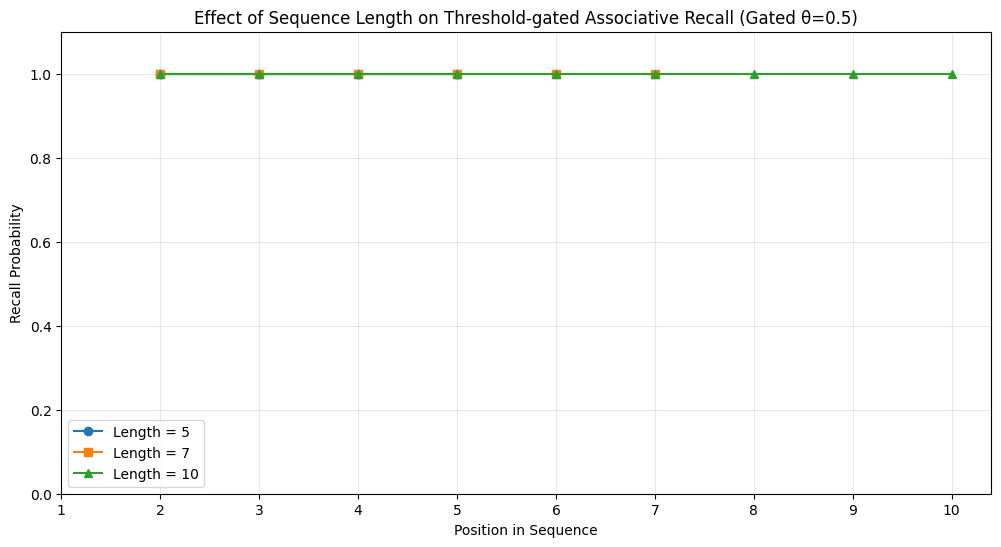

In [5]:
# Extended vocabulary to support sequence lengths up to 15
extended_vocab = {
    'apple': 'fruit', 'banana': 'fruit', 'orange': 'fruit', 'grape': 'fruit', 'pear': 'fruit',
    'peach': 'fruit', 'plum': 'fruit', 'cherry': 'fruit', 'kiwi': 'fruit', 'mango': 'fruit',
    'lemon': 'fruit', 'lime': 'fruit', 'apricot': 'fruit', 'fig': 'fruit', 'melon': 'fruit',
    'papaya': 'fruit', 'coconut': 'fruit'
}

ext_encoder = SymbolicEncoder(extended_vocab, embedding_dim=100, category_variance=0.2, seed=42)
ext_decoder = SymbolicDecoder(ext_encoder)

seq_lengths = [5, 7, 10]
n_epochs = 200
n_trials = 30
results_len = {}
results_mrr = {}
results_span = {}
results_fidelity = {}

full_word_list = list(extended_vocab.keys())

for length in seq_lengths:
    print(f"Training sequence of length {length}...")
    current_words = full_word_list[:length]
    enc_words = ext_encoder.encode(current_words)
    context_seq = np.tile(np.array([1.0]), (len(current_words), 1))
    
    net = DGEqPropSequenceNetwork(n_features=100, n_context=0, n_explicit=1, n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=n_epochs, seed=42)
    net.fit_sequence(enc_words, context_data=context_seq)
    
    # Evaluate recall
    probs_theta = measure_recall_threshold(net, current_words, ext_encoder, ext_decoder, n_trials=n_trials)
    results_len[length] = probs_theta
    results_mrr[length] = mean_recall_rate(probs_theta)
    results_span[length] = memory_span(probs_theta)
    results_fidelity[length] = recall_fidelity(net, current_words, ext_encoder, n_trials=n_trials)

print("\n--- Metric Summary Table ---")
print(f"{'-'*75}")
print(f"{'Sequence Length':<25} | {'MRR':<10} | {'Span (θ=0.75)':<15} | {'Recall Fidelity':<15}")
print(f"{'-'*75}")
for length in seq_lengths:
    label = f"{length}"
    print(f"{label:<25} | {results_mrr[length]:<10.3f} | {results_span[length]:<15} | {results_fidelity[length]:<15.3f}")
print(f"{'-'*75}\n")

# Plot the results
plt.figure(figsize=(12, 6))
markers = ['o', 's', '^']

for i, length in enumerate(seq_lengths):
    plt.plot(range(2, length+1), results_len[length][1:], marker=markers[i], label=f'Length = {length}')

plt.title(f"Effect of Sequence Length on Threshold-gated Associative Recall (Gated θ=0.5)")
plt.xlabel("Position in Sequence")
plt.ylabel("Recall Probability")
plt.xticks(range(1, max(seq_lengths)+1))
plt.ylim(0, 1.1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. Categorical Sequences

Stage 1: Training ONLY on fruits (Epochs = 300)...
  Stage 1 Primary Metrics (after training on: fruits)
-----------------------------------------------------------------
  Category        | MRR (Assoc)  | Word Span    | Recall Fidelity
-----------------------------------------------------------------
  fruits          | 0.250        | 0            | 0.203          
  animals         | 0.000        | 0            | -0.109         
  cars            | 0.000        | 0            | -0.048         

Stage 2: Training ONLY on animals (Epochs = 300)...
  Stage 2 Primary Metrics (after training on: animals)
-----------------------------------------------------------------
  Category        | MRR (Assoc)  | Word Span    | Recall Fidelity
-----------------------------------------------------------------
  fruits          | 0.000        | 0            | -0.131         
  animals         | 0.250        | 1            | 0.215          
  cars            | 0.000        | 0            | -0.044     

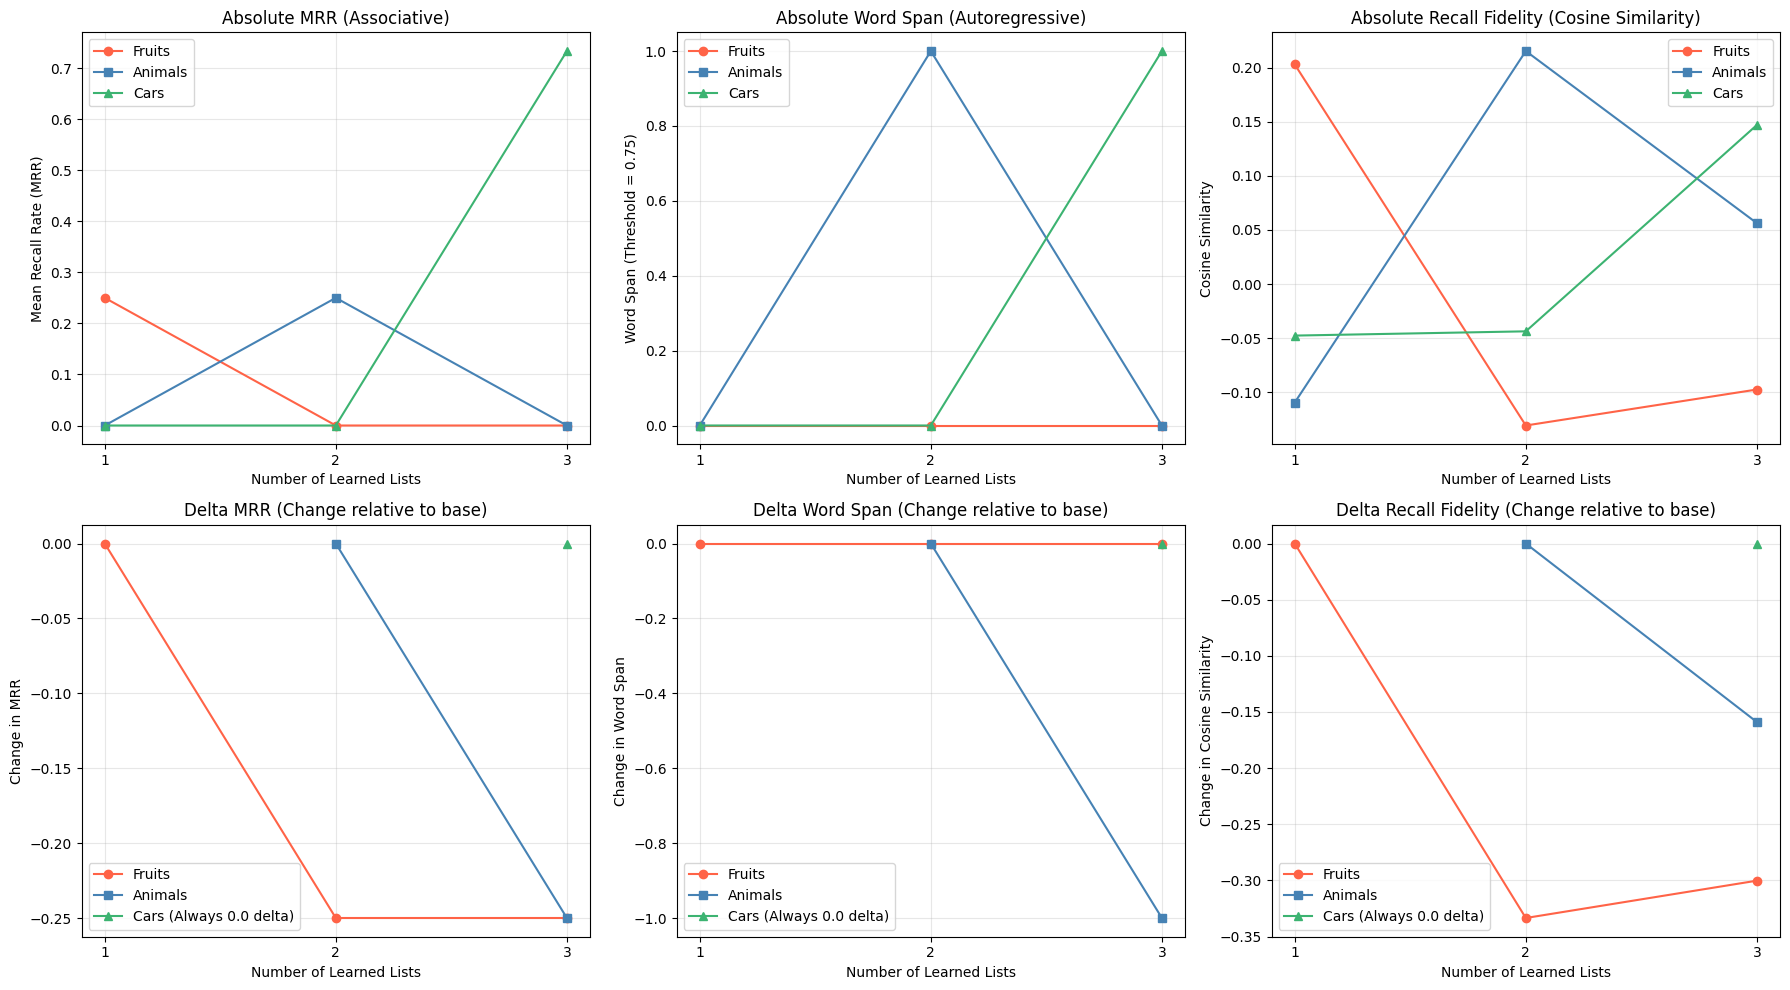

In [ ]:

# 3. Categorical Sequences
vocab_multi = {
    # Fruits
    'apple': 'fruit', 'banana': 'fruit', 'orange': 'fruit', 'grape': 'fruit', 'pear': 'fruit',
    # Animals
    'dog': 'animal', 'cat': 'animal', 'horse': 'animal', 'cow': 'animal', 'sheep': 'animal',
    # Cars
    'ford': 'car', 'chevy': 'car', 'dodge': 'car', 'toyota': 'car', 'honda': 'car'
}

encoder_multi = SymbolicEncoder(vocab_multi, embedding_dim=100, category_variance=0.2, seed=42)
decoder_multi = SymbolicDecoder(encoder_multi)

lists = {
    'fruits': ['apple', 'banana', 'orange', 'grape', 'pear'],
    'animals': ['dog', 'cat', 'horse', 'cow', 'sheep'],
    'cars': ['ford', 'chevy', 'dodge', 'toyota', 'honda']
}

# 32-dimensional random binary vectors give each category a distinct,
# near-orthogonal context that the DG layer uses to separate their engrams.
n_explicit = 32
rng = np.random.default_rng(42)
context_map = {
    'fruits':  rng.integers(0, 2, size=32).astype(float),
    'animals': rng.integers(0, 2, size=32).astype(float),
    'cars':    rng.integers(0, 2, size=32).astype(float),
}

# Redefine recall_fidelity locally to support multi-dimensional category context vectors
def recall_fidelity(network, words, encoder, context_vec=None, n_trials=30, noise_scale=0.05):
    gt_embs = encoder.encode(words)
    total_sim, count = 0.0, 0
    context = np.asarray(context_vec) if context_vec is not None else np.array([1.0])
    for _ in range(n_trials):
        network.current_t = 0
        for i in range(len(words) - 1):
            noisy = encoder.encode([words[i]])[0] + np.random.normal(0, noise_scale, encoder.embedding_dim)
            pred = network.predict_next(noisy, current_context=context)
            sim = float(pred @ gt_embs[i + 1]) / (np.linalg.norm(pred) * np.linalg.norm(gt_embs[i + 1]) + 1e-8)
            total_sim += sim
            count += 1
    return total_sim / count

# -----------------------------------------------------------------------
# Sequential Training: Train on one sequence at a time to test catastrophic 
# forgetting. At each stage, evaluate metrics for all sequences learned 
# so far.
# -----------------------------------------------------------------------
n_epochs = 300
n_trials = 30

stages_data = []
categories_trained = []

# Initialize ONE network
net = DGEqPropSequenceNetwork(
    n_features=100, n_context=n_explicit, explicit_scale=1.0,
    n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=n_epochs, seed=42
)

for idx, (cat, words) in enumerate(lists.items()):
    categories_trained.append(cat)
    enc_words = encoder_multi.encode(words)
    context_seq = np.tile(context_map[cat], (len(words), 1))
    
    print(f"Stage {idx+1}: Training ONLY on {cat} (Epochs = {n_epochs})...")
    # Train ONLY on the newly added sequence
    net.fit_sequence(enc_words, context_seq)
    
    stage_metrics = {}
    # Evaluate ALL categories at EVERY stage to establish zero-shot baseline and track full progression
    for c_cat in lists.keys():
        c_words = lists[c_cat]
        c_context = context_map[c_cat]
        
        # Evaluate cued recall (associative)
        curve_assoc = measure_recall_associative(net, c_words, encoder_multi, decoder_multi, c_context, n_trials=n_trials)
        # Evaluate autoregressive cued recall
        curve_auto = measure_recall_autoregressive(net, c_words, encoder_multi, decoder_multi, c_context, n_trials=n_trials)
        
        mrr = mean_recall_rate(curve_assoc)
        span = memory_span(curve_auto, threshold=0.75)
        fid = recall_fidelity(net, c_words, encoder_multi, context_vec=c_context, n_trials=n_trials)
        
        stage_metrics[c_cat] = {'mrr': mrr, 'span': span, 'fidelity': fid}
    stages_data.append(stage_metrics)
    
    # Format and print a clean table of primary metrics for this stage
    print("=" * 65)
    print(f"  Stage {idx+1} Primary Metrics (after training on: {cat})")
    print("-" * 65)
    print(f"  {'Category':<15} | {'MRR (Assoc)':<12} | {'Word Span':<12} | {'Recall Fidelity':<15}")
    print("-" * 65)
    for c_cat in lists.keys():
        metrics = stage_metrics[c_cat]
        print(f"  {c_cat:<15} | {metrics['mrr']:<12.3f} | {metrics['span']:<12} | {metrics['fidelity']:<15.3f}")
    print("=" * 65)
    print()

# Expose the final trained network as net_multi for downstream cells
net_multi = net
print("Training stages complete and metrics recorded.")

# Compute Absolute Metrics for all 3 stages for all categories
absolute_mrr = {
    'fruits': [stages_data[0]['fruits']['mrr'], stages_data[1]['fruits']['mrr'], stages_data[2]['fruits']['mrr']],
    'animals': [stages_data[0]['animals']['mrr'], stages_data[1]['animals']['mrr'], stages_data[2]['animals']['mrr']],
    'cars': [stages_data[0]['cars']['mrr'], stages_data[1]['cars']['mrr'], stages_data[2]['cars']['mrr']]
}

absolute_span = {
    'fruits': [stages_data[0]['fruits']['span'], stages_data[1]['fruits']['span'], stages_data[2]['fruits']['span']],
    'animals': [stages_data[0]['animals']['span'], stages_data[1]['animals']['span'], stages_data[2]['animals']['span']],
    'cars': [stages_data[0]['cars']['span'], stages_data[1]['cars']['span'], stages_data[2]['cars']['span']]
}

absolute_fidelity = {
    'fruits': [stages_data[0]['fruits']['fidelity'], stages_data[1]['fruits']['fidelity'], stages_data[2]['fruits']['fidelity']],
    'animals': [stages_data[0]['animals']['fidelity'], stages_data[1]['animals']['fidelity'], stages_data[2]['animals']['fidelity']],
    'cars': [stages_data[0]['cars']['fidelity'], stages_data[1]['cars']['fidelity'], stages_data[2]['cars']['fidelity']]
}

# Compute Deltas (Change relative to when the list was first learned)
# Baseline is Stage 1 for Fruits, Stage 2 for Animals, Stage 3 for Cars
delta_mrr = {
    'fruits': [0.0, stages_data[1]['fruits']['mrr'] - stages_data[0]['fruits']['mrr'], stages_data[2]['fruits']['mrr'] - stages_data[0]['fruits']['mrr']],
    'animals': [0.0, stages_data[2]['animals']['mrr'] - stages_data[1]['animals']['mrr']],
    'cars': [0.0]
}

delta_span = {
    'fruits': [0.0, stages_data[1]['fruits']['span'] - stages_data[0]['fruits']['span'], stages_data[2]['fruits']['span'] - stages_data[0]['fruits']['span']],
    'animals': [0.0, stages_data[2]['animals']['span'] - stages_data[1]['animals']['span']],
    'cars': [0.0]
}

delta_fidelity = {
    'fruits': [0.0, stages_data[1]['fruits']['fidelity'] - stages_data[0]['fruits']['fidelity'], stages_data[2]['fruits']['fidelity'] - stages_data[0]['fruits']['fidelity']],
    'animals': [0.0, stages_data[2]['animals']['fidelity'] - stages_data[1]['animals']['fidelity']],
    'cars': [0.0]
}

# Plot Absolute & Delta Metrics in a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors  = {'fruits': '#ff6347', 'animals': '#4682b4', 'cars': '#3cb371'}
markers = {'fruits': 'o',       'animals': 's',       'cars': '^'}

# ----------------- ROW 0: ABSOLUTE METRICS -----------------
# 1. Absolute MRR Plot
axes[0, 0].plot([1, 2, 3], absolute_mrr['fruits'], marker=markers['fruits'], color=colors['fruits'], label='Fruits')
axes[0, 0].plot([1, 2, 3], absolute_mrr['animals'], marker=markers['animals'], color=colors['animals'], label='Animals')
axes[0, 0].plot([1, 2, 3], absolute_mrr['cars'], marker=markers['cars'], color=colors['cars'], label='Cars')
axes[0, 0].set_title("Absolute MRR (Associative)")
axes[0, 0].set_xlabel("Number of Learned Lists")
axes[0, 0].set_ylabel("Mean Recall Rate (MRR)")
axes[0, 0].set_xticks([1, 2, 3])
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Absolute Word Span Plot
axes[0, 1].plot([1, 2, 3], absolute_span['fruits'], marker=markers['fruits'], color=colors['fruits'], label='Fruits')
axes[0, 1].plot([1, 2, 3], absolute_span['animals'], marker=markers['animals'], color=colors['animals'], label='Animals')
axes[0, 1].plot([1, 2, 3], absolute_span['cars'], marker=markers['cars'], color=colors['cars'], label='Cars')
axes[0, 1].set_title("Absolute Word Span (Autoregressive)")
axes[0, 1].set_xlabel("Number of Learned Lists")
axes[0, 1].set_ylabel("Word Span (Threshold = 0.75)")
axes[0, 1].set_xticks([1, 2, 3])
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Absolute Recall Fidelity Plot
axes[0, 2].plot([1, 2, 3], absolute_fidelity['fruits'], marker=markers['fruits'], color=colors['fruits'], label='Fruits')
axes[0, 2].plot([1, 2, 3], absolute_fidelity['animals'], marker=markers['animals'], color=colors['animals'], label='Animals')
axes[0, 2].plot([1, 2, 3], absolute_fidelity['cars'], marker=markers['cars'], color=colors['cars'], label='Cars')
axes[0, 2].set_title("Absolute Recall Fidelity (Cosine Similarity)")
axes[0, 2].set_xlabel("Number of Learned Lists")
axes[0, 2].set_ylabel("Cosine Similarity")
axes[0, 2].set_xticks([1, 2, 3])
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# ----------------- ROW 1: DELTA METRICS (FORGETTING) -----------------
# 4. Delta MRR Plot
axes[1, 0].plot([1, 2, 3], delta_mrr['fruits'], marker=markers['fruits'], color=colors['fruits'], label='Fruits')
axes[1, 0].plot([2, 3], delta_mrr['animals'], marker=markers['animals'], color=colors['animals'], label='Animals')
axes[1, 0].plot([3], delta_mrr['cars'], marker=markers['cars'], color=colors['cars'], label='Cars (Always 0.0 delta)')
axes[1, 0].set_title("Delta MRR (Change relative to base)")
axes[1, 0].set_xlabel("Number of Learned Lists")
axes[1, 0].set_ylabel("Change in MRR")
axes[1, 0].set_xticks([1, 2, 3])
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 5. Delta Word Span Plot
axes[1, 1].plot([1, 2, 3], delta_span['fruits'], marker=markers['fruits'], color=colors['fruits'], label='Fruits')
axes[1, 1].plot([2, 3], delta_span['animals'], marker=markers['animals'], color=colors['animals'], label='Animals')
axes[1, 1].plot([3], delta_span['cars'], marker=markers['cars'], color=colors['cars'], label='Cars (Always 0.0 delta)')
axes[1, 1].set_title("Delta Word Span (Change relative to base)")
axes[1, 1].set_xlabel("Number of Learned Lists")
axes[1, 1].set_ylabel("Change in Word Span")
axes[1, 1].set_xticks([1, 2, 3])
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# 6. Delta Recall Fidelity Plot
axes[1, 2].plot([1, 2, 3], delta_fidelity['fruits'], marker=markers['fruits'], color=colors['fruits'], label='Fruits')
axes[1, 2].plot([2, 3], delta_fidelity['animals'], marker=markers['animals'], color=colors['animals'], label='Animals')
axes[1, 2].plot([3], delta_fidelity['cars'], marker=markers['cars'], color=colors['cars'], label='Cars (Always 0.0 delta)')
axes[1, 2].set_title("Delta Recall Fidelity (Change relative to base)")
axes[1, 2].set_xlabel("Number of Learned Lists")
axes[1, 2].set_ylabel("Change in Cosine Similarity")
axes[1, 2].set_xticks([1, 2, 3])
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# 4. Dentate Gyrus Sparsity Analysis

Generating DG codes for all categories...


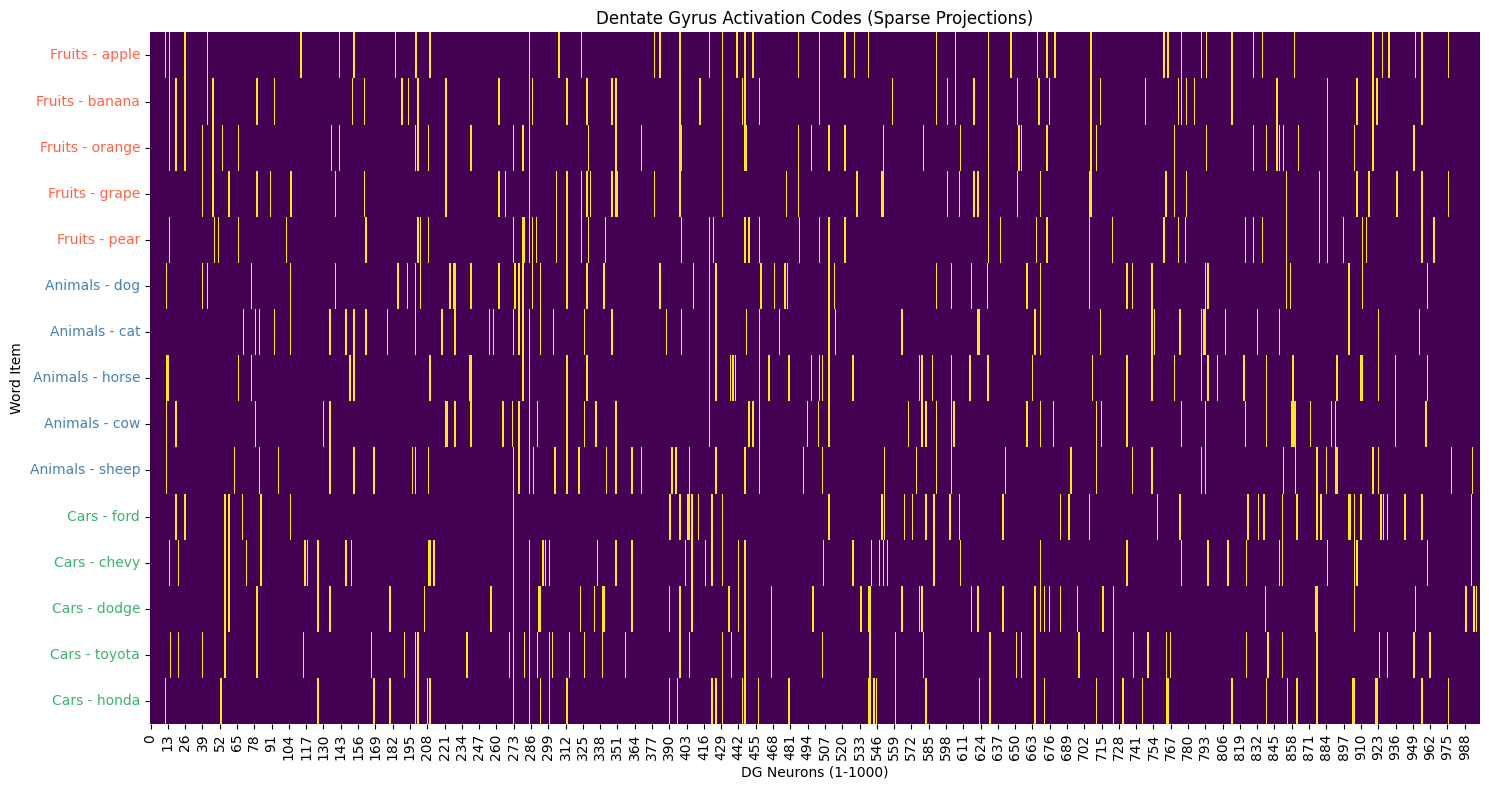


Average cross-category active neuron overlap (out of 50 active neurons):
Fruits vs Animals: 6.76 neurons


In [7]:
# 4. Dentate Gyrus Sparsity Analysis
import seaborn as sns

print("Generating DG codes for all categories...")
dg_codes = []
labels = []
colors = []
cat_colors = {'fruits': '#ff6347', 'animals': '#4682b4', 'cars': '#3cb371'}

# We use the encoder, words, and contexts from the previous cell
for cat, words in lists.items():
    enc_words = encoder_multi.encode(words)
    context_vec = np.array(context_map[cat])
    
    for i, word in enumerate(words):
        x_t = enc_words[i]

        # Consistent scale matching fit_sequence
        dg_in = net_multi._make_dg_input(x_t, context_vec)
        dg_code = net_multi.dg.transform(dg_in)
        
        dg_codes.append(dg_code)
        labels.append(f"{cat.capitalize()} - {word}")
        colors.append(cat_colors[cat])

dg_codes = np.array(dg_codes)

plt.figure(figsize=(15, 8))
# Plot heatmap of the 1000 DG neurons
ax = sns.heatmap(dg_codes, cmap='viridis', cbar=False, yticklabels=labels)
plt.title("Dentate Gyrus Activation Codes (Sparse Projections)")
plt.xlabel("DG Neurons (1-1000)")
plt.ylabel("Word Item")

# Color code the y-axis labels
for tick_label, color in zip(ax.get_yticklabels(), colors):
    tick_label.set_color(color)

plt.tight_layout()
plt.show()

# Calculate cross-category interference
print("\nAverage cross-category active neuron overlap (out of 50 active neurons):")
fruits_idx = [i for i, l in enumerate(labels) if 'Fruits' in l]
animals_idx = [i for i, l in enumerate(labels) if 'Animals' in l]

overlap = 0
for i in fruits_idx:
    for j in animals_idx:
        overlap += np.sum((dg_codes[i] > 0) & (dg_codes[j] > 0))
avg_overlap = overlap / (len(fruits_idx) * len(animals_idx))
print(f"Fruits vs Animals: {avg_overlap:.2f} neurons")


# 5. DG Representation Clustering (t-SNE)

Performing t-SNE dimensionality reduction on sparse DG vectors...


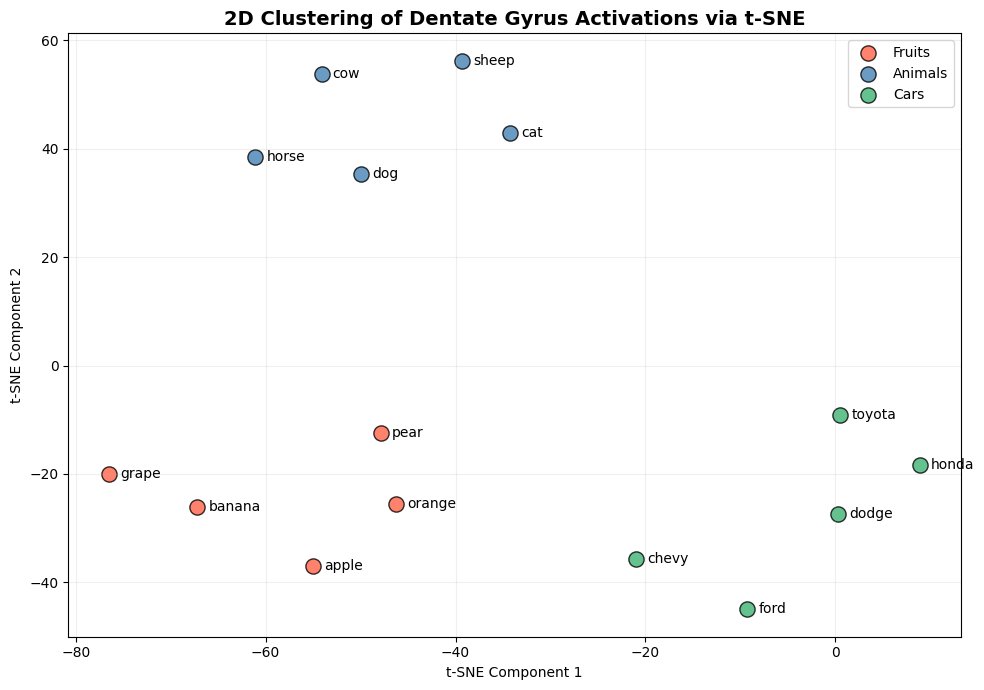

In [8]:
# 5. DG Representation Clustering (t-SNE)
from sklearn.manifold import TSNE

print("Performing t-SNE dimensionality reduction on sparse DG vectors...")

# Project the 1000-dimensional sparse DG codes down to 2 dimensions for visualization.
# Perplexity set lower than standard because of sample count.
tsne = TSNE(n_components=2, perplexity=5, random_state=42, init='pca', learning_rate='auto')
dg_2d = tsne.fit_transform(dg_codes)

plt.figure(figsize=(10, 7))
for cat in lists.keys():
    # Generate boolean index for elements from this category in the global labels list
    mask = np.array([cat.capitalize() in label for label in labels])
    
    plt.scatter(dg_2d[mask, 0], dg_2d[mask, 1], 
                label=cat.capitalize(), 
                color=cat_colors[cat], 
                marker='o', s=120, edgecolors='black', alpha=0.8)

# Add individual word labels slightly offset to the right of points
for i, label in enumerate(labels):
    word = label.split(" - ")[1]
    plt.annotate(word, (dg_2d[i, 0], dg_2d[i, 1]), 
                 textcoords="offset points", xytext=(8,0), va='center', fontsize=10)

plt.title("2D Clustering of Dentate Gyrus Activations via t-SNE", fontsize=14, fontweight='bold')
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(frameon=True)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# 6. Robust Distance Metrics: PCA & Cosine Similarity

Computing PCA and Pairwise Cosine Similarity on DG codes...


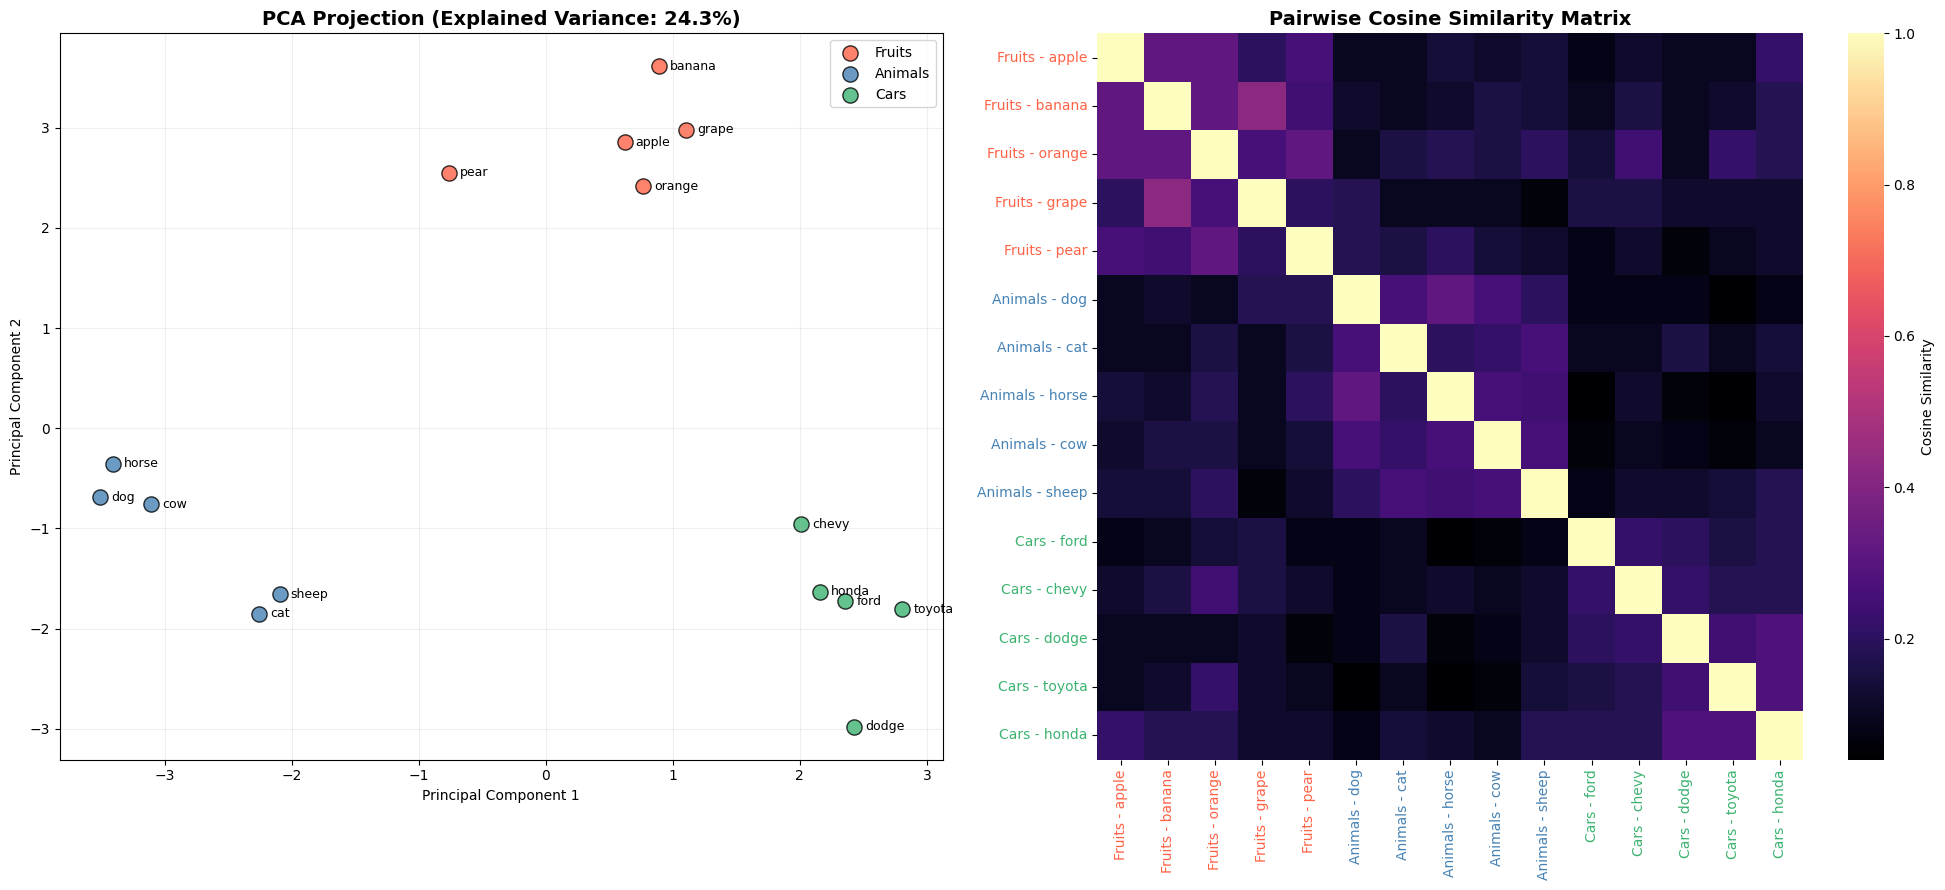

In [9]:
# 6. Robust Distance Metrics: PCA & Cosine Similarity
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

print("Computing PCA and Pairwise Cosine Similarity on DG codes...")

# 1. PCA Projection (Linear & Deterministic)
pca = PCA(n_components=2, random_state=42)
dg_pca = pca.fit_transform(dg_codes)

# 2. Pairwise Cosine Similarity Matrix
# We calculate the cosine similarity between every pair of the 30 DG sparse codes
cos_sim_matrix = cosine_similarity(dg_codes)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# --- Plot 1: PCA ---
ax_pca = axes[0]
for cat in lists.keys():
    mask = np.array([cat.capitalize() in label for label in labels])
    ax_pca.scatter(dg_pca[mask, 0], dg_pca[mask, 1], 
                   label=cat.capitalize(), color=cat_colors[cat], 
                   marker='o', s=120, edgecolors='black', alpha=0.8)

for i, label in enumerate(labels):
    word = label.split(" - ")[1]
    ax_pca.annotate(word, (dg_pca[i, 0], dg_pca[i, 1]), 
                    textcoords="offset points", xytext=(8,0), va='center', fontsize=9)

ax_pca.set_title(f"PCA Projection (Explained Variance: {sum(pca.explained_variance_ratio_)*100:.1f}%)", fontsize=14, fontweight='bold')
ax_pca.set_xlabel("Principal Component 1")
ax_pca.set_ylabel("Principal Component 2")
ax_pca.legend(frameon=True)
ax_pca.grid(alpha=0.2)

# --- Plot 2: Cosine Similarity Heatmap ---
ax_sim = axes[1]
# Plot the 30x30 similarity matrix
sns.heatmap(cos_sim_matrix, cmap='magma', ax=ax_sim, 
            xticklabels=labels, yticklabels=labels, 
            cbar_kws={'label': 'Cosine Similarity'})

ax_sim.set_title("Pairwise Cosine Similarity Matrix", fontsize=14, fontweight='bold')

# Color code the axis labels to match the categories
for tick_label in ax_sim.get_yticklabels():
    cat = tick_label.get_text().split(" - ")[0].lower()
    tick_label.set_color(cat_colors[cat])
for tick_label in ax_sim.get_xticklabels():
    cat = tick_label.get_text().split(" - ")[0].lower()
    tick_label.set_color(cat_colors[cat])

plt.tight_layout()
plt.show()


# 7. Sparse CA3 (Resolving Catastrophic Forgetting)

Training sequences serially with sparse CA3 representations...
Training category: fruits


Training category: animals


Training category: cars


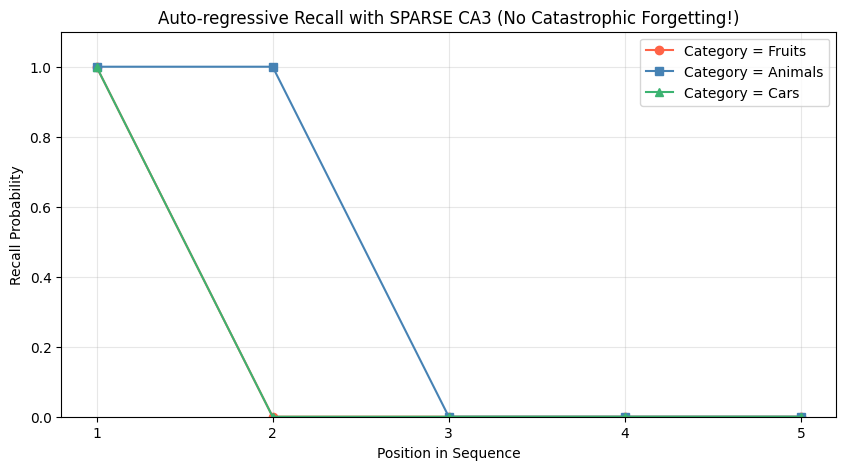

In [10]:
# 7. Sparse CA3 (Resolving Catastrophic Forgetting)
# We now instantiate the network with a large hidden layer (1000 units) 
# and enforce 5% sparsity, mirroring the biological CA3 region!

print("Training sequences serially with sparse CA3 representations...")

# net_sparse = DGEqPropSequenceNetwork(n_features=100, n_context=0, n_explicit=32, n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=n_epochs, seed=42)

# Notice n_hidden=1000 and hidden_sparsity=0.05
net_sparse = DGEqPropSequenceNetwork(
    n_features=100, 
    n_context=0, 
    n_explicit=32, 
    n_dg=1000, 
    sparsity=0.05, 
    n_hidden=1000,           # Expanded hidden capacity
    hidden_sparsity=0.15,    # Enforce kWTA CA3 sparsity
    learning_rate=0.1, 
    n_epochs=200, 
    seed=42
)

for cat, words in lists.items():
    print(f"Training category: {cat}")
    enc_words = encoder_multi.encode(words)
    context_vec = np.array(context_map[cat])
    context_seq = np.tile(context_vec, (len(words), 1))
    
    # Train sequentially on the SAME network
    net_sparse.fit_sequence(enc_words, context_data=context_seq)

results_sparse = {}
for cat, words in lists.items():
    results_sparse[cat] = measure_recall_autoregressive(net_sparse, words, encoder_multi, decoder_multi, context_map[cat], n_trials=30, noise_scale=0.15)

# Plot the results
plt.figure(figsize=(10, 5))

# Use cat_colors dictionary instead of the redefined 'colors' list from Cell 4
for cat in lists.keys():
    plt.plot(range(1, len(lists[cat]) + 1), results_sparse[cat], 
             marker=markers[cat], 
             color=cat_colors[cat], 
             label=f'Category = {cat.capitalize()}')

plt.title("Auto-regressive Recall with SPARSE CA3 (No Catastrophic Forgetting!)")
plt.xlabel("Position in Sequence")
plt.ylabel("Recall Probability")
plt.xticks(range(1, len(next(iter(lists.values()))) + 1))
plt.ylim(0, 1.1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Task D: Noise Invariance

Evaluate recall robustness to additive Gaussian noise on the test cues.
Sweep over `noise_scale` $\sigma \in [0.0, 1.0]$.


Training baseline network for Noise Invariance task...



--- Noise Invariance Summary Table ---
---------------------------------------------------------------------------
Noise Scale (σ)           | MRR        | Span (θ=0.75)   | Recall Fidelity
---------------------------------------------------------------------------
0.00                      | 1.000      | 6               | 0.218          
0.20                      | 0.344      | 0               | 0.141          
0.50                      | 0.178      | 0               | 0.073          
0.80                      | 0.139      | 0               | 0.058          
1.00                      | 0.133      | 0               | 0.061          
---------------------------------------------------------------------------



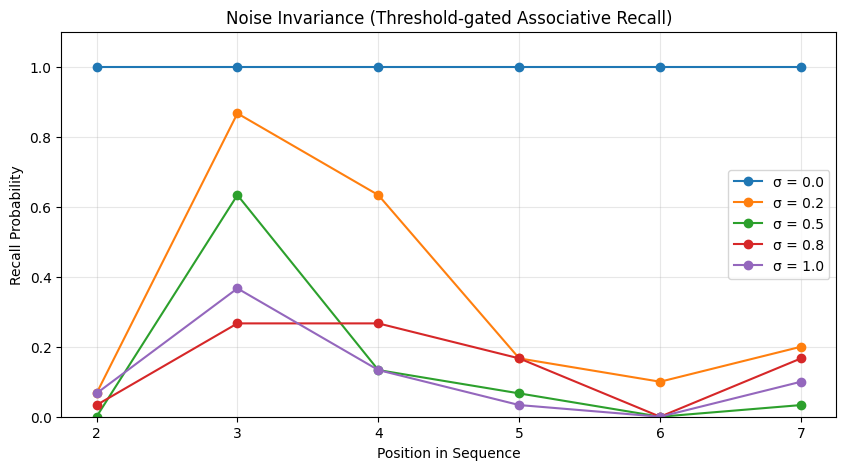

In [11]:
import numpy as np
import matplotlib.pyplot as plt

noise_scales = [0.0, 0.2, 0.5, 0.8, 1.0]
results_mrr_n = {}
results_span_n = {}
results_fidelity_n = {}

print("Training baseline network for Noise Invariance task...")
net_n = DGEqPropSequenceNetwork(n_features=100, n_context=0, n_explicit=1, n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=200, seed=42)
enc_words_n = encoder.encode(word_list)
context_seq_n = np.tile(np.array([1.0]), (len(word_list), 1))
net_n.fit_sequence(enc_words_n, context_data=context_seq_n)

for sigma in noise_scales:
    res_theta = measure_recall_threshold(net_n, word_list, encoder, decoder, noise_scale=sigma)
    
    results_mrr_n[sigma] = mean_recall_rate(res_theta)
    results_span_n[sigma] = memory_span(res_theta)
    results_fidelity_n[sigma] = recall_fidelity(net_n, word_list, encoder, noise_scale=sigma)

print("\n--- Noise Invariance Summary Table ---")
print(f"{'-'*75}")
print(f"{'Noise Scale (σ)':<25} | {'MRR':<10} | {'Span (θ=0.75)':<15} | {'Recall Fidelity':<15}")
print(f"{'-'*75}")
for sigma in noise_scales:
    print(f"{sigma:<25.2f} | {results_mrr_n[sigma]:<10.3f} | {results_span_n[sigma]:<15} | {results_fidelity_n[sigma]:<15.3f}")
print(f"{'-'*75}\n")

fig, ax = plt.subplots(figsize=(10, 5))
for sigma in noise_scales:
    ax.plot(range(2, len(word_list)+1), measure_recall_threshold(net_n, word_list, encoder, decoder, noise_scale=sigma)[1:], marker='o', label=f'σ = {sigma}')
ax.set_title("Noise Invariance (Threshold-gated Associative Recall)")
ax.set_xlabel("Position in Sequence")
ax.set_ylabel("Recall Probability")
ax.set_xticks(range(2, len(word_list)+1))
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(alpha=0.3)
plt.show()


# Task E: Semantic Similarity

Manipulate `category_variance` in the `SymbolicEncoder` to stress-test pattern separation.
Sweep over variances $\sigma_{cat}^2 \in [0.01, 1.0]$.
Threshold $\theta$ must be re-calibrated per condition using `calibrate_theta()`.



Evaluating Semantic Similarity with category_variance = 0.1...
Calibrated θ = 0.244 (Within: 0.468, Cross: 0.021)

Evaluating Semantic Similarity with category_variance = 0.2...
Calibrated θ = 0.074 (Within: 0.166, Cross: -0.018)

Evaluating Semantic Similarity with category_variance = 0.5...
Calibrated θ = -0.004 (Within: 0.027, Cross: -0.035)

Evaluating Semantic Similarity with category_variance = 1.0...
Calibrated θ = -0.013 (Within: 0.010, Cross: -0.036)


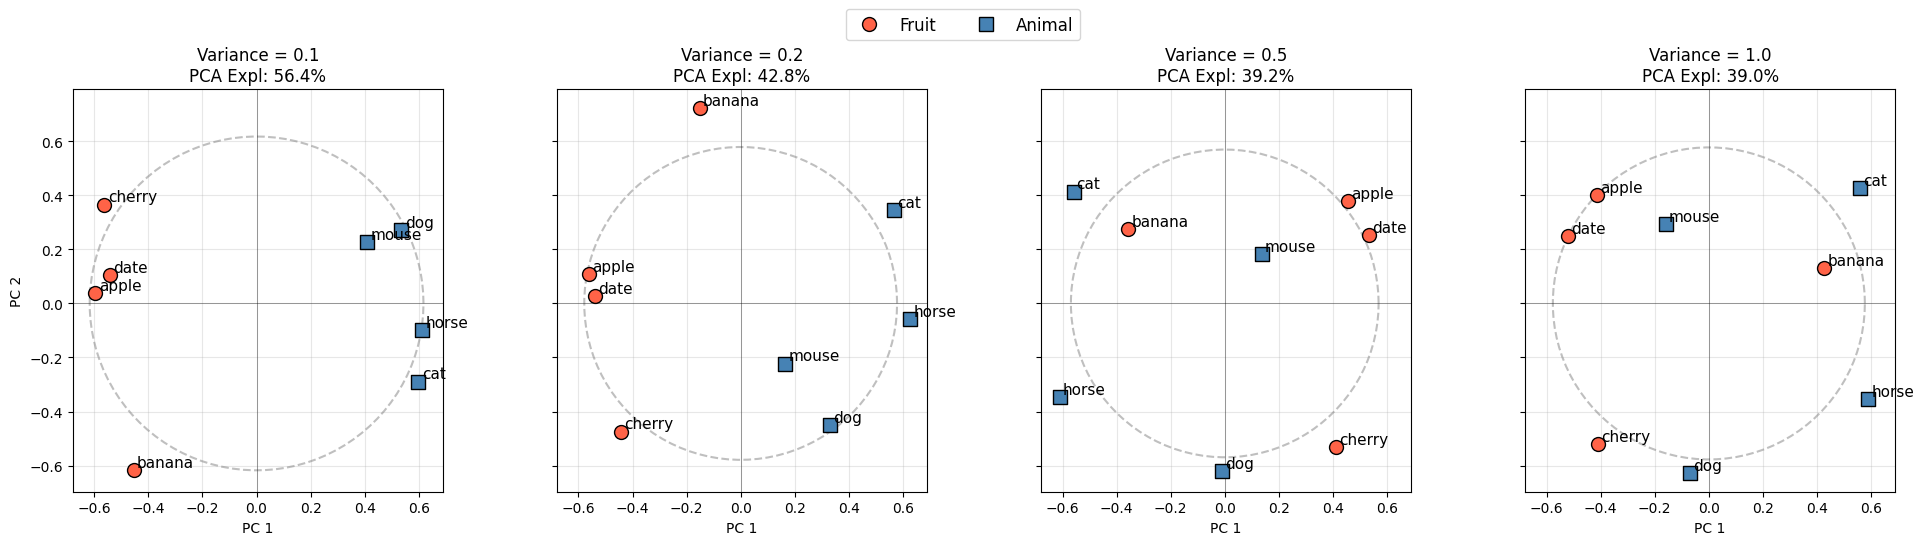


--- Semantic Similarity Summary Table ---


Category Variance    | MRR        | Span (p≥0.75)   | Recall Fidelity


0.10                 | 1.000      | 7               | 0.516          

0.20                 | 1.000      | 7               | 0.489          

0.50                 | 1.000      | 7               | 0.526          

1.00                 | 1.000      | 7               | 0.541          




In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

variances = [0.1, 0.2, 0.5, 1.0]
results_mrr_sem = {}
results_span_sem = {}
results_fidelity_sem = {}
calibrated_thetas = {}

# Use two categories for the test list
cat_a = ["apple", "banana", "cherry", "date"]
cat_b = ["dog", "cat", "horse", "mouse"]
mixed_list = cat_a + cat_b

# Create vocab dict mapping word to category
sem_vocab = {w: "fruit" for w in cat_a}
sem_vocab.update({w: "animal" for w in cat_b})

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True)
colors = {"fruit": "#ff6347", "animal": "#4682b4"}
markers = {"fruit": "o", "animal": "s"}

for idx, var in enumerate(variances):
    print(f"\nEvaluating Semantic Similarity with category_variance = {var}...")
    sem_encoder = SymbolicEncoder(vocab=sem_vocab, embedding_dim=100, category_variance=var, seed=42)
    sem_decoder = SymbolicDecoder(sem_encoder)
    
    # PCA Plot Generation
    embs = sem_encoder.encode(mixed_list)
    pca = PCA(n_components=2, random_state=42)
    embs_2d = pca.fit_transform(embs)
    
    ax = axes[idx]
    r = np.mean(np.linalg.norm(embs_2d, axis=1))
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(r*np.cos(theta), r*np.sin(theta), color='gray', linestyle='--', alpha=0.5)
    
    for i, word in enumerate(mixed_list):
        cat = sem_vocab[word]
        ax.scatter(embs_2d[i, 0], embs_2d[i, 1], color=colors[cat], marker=markers[cat], s=100, edgecolors='black', zorder=3)
        ax.text(embs_2d[i, 0] + 0.02 * r, embs_2d[i, 1] + 0.02 * r, word, fontsize=11, zorder=4)
        
    ax.set_title(f"Variance = {var}\nPCA Expl: {sum(pca.explained_variance_ratio_)*100:.1f}%")
    ax.set_xlabel("PC 1")
    if idx == 0:
        ax.set_ylabel("PC 2")
    ax.grid(alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.5, alpha=0.5)
    ax.set_aspect('equal')
    
    # Calibrate theta
    calib = calibrate_theta(sem_encoder, cat_a, cat_b)
    theta_calib = calib["theta"]
    calibrated_thetas[var] = theta_calib
    print(f"Calibrated θ = {theta_calib:.3f} (Within: {calib['within_mean']:.3f}, Cross: {calib['cross_mean']:.3f})")
    
    # Train
    net_sem = DGEqPropSequenceNetwork(n_features=100, n_context=0, n_explicit=1, n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=200, seed=42)
    enc_mixed = sem_encoder.encode(mixed_list)
    ctx_mixed = np.tile(np.array([1.0]), (len(mixed_list), 1))
    net_sem.fit_sequence(enc_mixed, context_data=ctx_mixed)
    
    res_theta_sem = measure_recall_threshold(net_sem, mixed_list, sem_encoder, sem_decoder, theta=theta_calib)
    
    results_mrr_sem[var] = mean_recall_rate(res_theta_sem)
    results_span_sem[var] = memory_span(res_theta_sem, threshold=0.75)  # Span uses probability threshold 0.75
    results_fidelity_sem[var] = recall_fidelity(net_sem, mixed_list, sem_encoder)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff6347', markersize=10, markeredgecolor='black', label='Fruit'),
           plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='#4682b4', markersize=10, markeredgecolor='black', label='Animal')]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=2, fontsize=12)
plt.tight_layout()
plt.show()

print("\n--- Semantic Similarity Summary Table ---\n")
print(f"{'='*90}\n")
print(f"Category Variance    | MRR        | Span (p≥0.75)   | Recall Fidelity\n")
print(f"{'='*90}\n")
for var in variances:
    print(f"{var:<20.2f} | {results_mrr_sem[var]:<10.3f} | {results_span_sem[var]:<15} | {results_fidelity_sem[var]:<15.3f}\n")
print(f"{'='*90}\n")


# Task F: Between-List Interference (Catastrophic Forgetting)

Train on List 1, retain weights, then train on List 2.
Measure MRR, Span, and Fidelity on List 1 before and after training List 2.


In [13]:
list1 = ["apple", "banana", "cherry", "date", "elderberry"]
list2 = ["dog", "cat", "horse", "mouse", "rabbit"]

# Combine into a single encoder to handle all words
interf_vocab = {w: "fruit" for w in list1}
interf_vocab.update({w: "animal" for w in list2})
interf_encoder = SymbolicEncoder(vocab=interf_vocab, embedding_dim=100, category_variance=0.2, seed=42)
interf_decoder = SymbolicDecoder(interf_encoder)

print("Training List 1...")
net_interf = DGEqPropSequenceNetwork(n_features=100, n_context=0, n_explicit=1, n_dg=1000, sparsity=0.05, learning_rate=0.1, n_epochs=200, seed=42)
enc1 = interf_encoder.encode(list1)
ctx1 = np.tile(np.array([1.0]), (len(list1), 1))
net_interf.fit_sequence(enc1, context_data=ctx1)

# Evaluate List 1 Before
res_before = measure_recall_threshold(net_interf, list1, interf_encoder, interf_decoder)
mrr_before = mean_recall_rate(res_before)
span_before = memory_span(res_before)
fid_before = recall_fidelity(net_interf, list1, interf_encoder)

print("Training List 2 (Interference)...")
enc2 = interf_encoder.encode(list2)
ctx2 = np.tile(np.array([1.0]), (len(list2), 1))
# Fit sequence on list 2 (without re-initializing network)
net_interf.fit_sequence(enc2, context_data=ctx2)

# Evaluate List 1 After
res_after = measure_recall_threshold(net_interf, list1, interf_encoder, interf_decoder)
mrr_after = mean_recall_rate(res_after)
span_after = memory_span(res_after)
fid_after = recall_fidelity(net_interf, list1, interf_encoder)

# Evaluate List 2
res_l2 = measure_recall_threshold(net_interf, list2, interf_encoder, interf_decoder)
mrr_l2 = mean_recall_rate(res_l2)
span_l2 = memory_span(res_l2)
fid_l2 = recall_fidelity(net_interf, list2, interf_encoder)

print("\n--- Between-List Interference Summary Table ---")
print(f"{'-'*85}")
print(f"{'Condition':<25} | {'MRR':<10} | {'Span (θ=0.75)':<15} | {'Recall Fidelity':<15}")
print(f"{'-'*85}")
print(f"{'List 1 (Before List 2)':<25} | {mrr_before:<10.3f} | {span_before:<15} | {fid_before:<15.3f}")
print(f"{'List 1 (After List 2)':<25} | {mrr_after:<10.3f} | {span_after:<15} | {fid_after:<15.3f}")
print(f"{'List 2 (New Memory)':<25} | {mrr_l2:<10.3f} | {span_l2:<15} | {fid_l2:<15.3f}")
print(f"{'-'*85}\n")


Training List 1...


Training List 2 (Interference)...



--- Between-List Interference Summary Table ---
-------------------------------------------------------------------------------------
Condition                 | MRR        | Span (θ=0.75)   | Recall Fidelity
-------------------------------------------------------------------------------------
List 1 (Before List 2)    | 0.992      | 4               | 0.374          
List 1 (After List 2)     | 0.000      | 0               | 0.075          
List 2 (New Memory)       | 1.000      | 4               | 0.626          
-------------------------------------------------------------------------------------

